<a href="https://colab.research.google.com/github/AlyxionCore40/Jupyter-Exploration/blob/main/L05__Chavez_Alexia_ITAI23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ITAI 2373 Module 05: Part-of-Speech Tagging
## In-Class Exercise & Homework Lab

Welcome to the world of Part-of-Speech (POS) tagging - the "grammar police" of Natural Language Processing! 🚔📝

In this notebook, you'll explore how computers understand the grammatical roles of words in sentences, from simple rule-based approaches to modern AI systems.

### What You'll Learn:
- **Understand POS tagging fundamentals** and why it matters in daily apps
- **Use NLTK and SpaCy** for practical text analysis
- **Navigate different tag sets** and understand their trade-offs
- **Handle real-world messy text** like speech transcripts and social media
- **Apply POS tagging** to solve actual business problems

### Structure:
- **Part 1**: In-Class Exercise (30-45 minutes) - Basic concepts and hands-on practice
- **Part 2**: Homework Lab - Real-world applications and advanced challenges

---

*💡 **Pro Tip**: POS tagging is everywhere! It helps search engines understand "Apple stock" vs "apple pie", helps Siri understand your commands, and powers autocorrect on your phone.*



## 🛠️ Setup and Installation

Let's get our tools ready! We'll use two powerful libraries:
- **NLTK**: The "Swiss Army knife" of NLP - comprehensive but requires setup
- **SpaCy**: The "speed demon" - built for production, cleaner output

Run the cells below to install and set up everything we need.


In [ ]:

# Install required libraries (run this first!)
!pip install nltk spacy matplotlib seaborn pandas
!python -m spacy download en_core_web_sm

print("✅ Installation complete!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 84.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Installation complete!


In [ ]:

# Import all the libraries we'll need
import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data (this might take a moment)
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('universal_tagset')

# Load SpaCy model
nlp = spacy.load('en_core_web_sm')

print("🎉 All libraries loaded successfully!")
print("📚 NLTK version:", nltk.__version__)
print("🚀 SpaCy version:", spacy.__version__)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.


🎉 All libraries loaded successfully!
📚 NLTK version: 3.9.1
🚀 SpaCy version: 3.8.11



---
# 🎯 PART 1: IN-CLASS EXERCISE (30-45 minutes)

Welcome to the hands-on portion! We'll start with the basics and build up your understanding step by step.

## Learning Goals for Part 1:
1. Understand what POS tagging does
2. Use NLTK and SpaCy for basic tagging
3. Interpret and compare different tag outputs
4. Explore word ambiguity with real examples
5. Compare different tagging approaches



## 🔍 Activity 1: Your First POS Tags (10 minutes)

Let's start with the classic example: "The quick brown fox jumps over the lazy dog"

This sentence contains most common parts of speech, making it perfect for learning!


In [ ]:
import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

sentence = "The quick brown fox jumps over the lazy dog"

tokens = nltk.word_tokenize(sentence)
pos_tags = nltk.pos_tag(tokens)

print("Original sentence:", sentence)
print("\nTokens:", tokens)
print("\nPOS Tags:")
for word, tag in pos_tags:
    print(f"  {word:8} -> {tag}")


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Original sentence: The quick brown fox jumps over the lazy dog

Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']

POS Tags:
  The      -> DT
  quick    -> JJ
  brown    -> NN
  fox      -> NN
  jumps    -> VBZ
  over     -> IN
  the      -> DT
  lazy     -> JJ
  dog      -> NN



### 🤔 Quick Questions:
1. What does 'DT' mean? What about 'JJ'?
'DT' stands for Determiner such words like "the", "a", "an" that introduce nouns. 'JJ' stands for Adjective which are  words that describe or modify nouns.
2. Why do you think 'brown' and 'lazy' have the same tag?Both are adjectives that modify nouns ("brown fox", "lazy dog"), so they both get tagged 'JJ'. POS tagging links grammatical function, not meaning so both words play the exact same grammatical role in the sentence.
3. Can you guess what 'VBZ' represents?'VBZ' stands for Verb, 3rd person singular which present "jumps" int this case. The breakdown is: V = verb, B = "be" family base, Z = third-person singular (the "s" ending). So "he jumps", "she runs", "it barks" would all get VBZ.

*Hint: Think about the grammatical role each word plays in the sentence!*



## 🚀 Activity 2: SpaCy vs NLTK Showdown (10 minutes)

Now let's see how SpaCy handles the same sentence. SpaCy uses cleaner, more intuitive tag names.


In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

doc = nlp(sentence)

print("SpaCy POS Tags:")
for token in doc:
    print(f"  {token.text:8} -> {token.pos_:6} ({token.tag_})")

print("\n" + "="*50)
print("COMPARISON:")
print("="*50)

nltk_tags = nltk.pos_tag(nltk.word_tokenize(sentence))
spacy_doc = nlp(sentence)

print(f"{'Word':10} {'NLTK':8} {'SpaCy':10}")
print("-" * 30)
for i, (word, nltk_tag) in enumerate(nltk_tags):
    spacy_tag = spacy_doc[i].pos_
    print(f"{word:10} {nltk_tag:8} {spacy_tag:10}")


SpaCy POS Tags:
  The      -> DET    (DT)
  quick    -> ADJ    (JJ)
  brown    -> ADJ    (JJ)
  fox      -> NOUN   (NN)
  jumps    -> VERB   (VBZ)
  over     -> ADP    (IN)
  the      -> DET    (DT)
  lazy     -> ADJ    (JJ)
  dog      -> NOUN   (NN)

COMPARISON:
Word       NLTK     SpaCy     
------------------------------
The        DT       DET       
quick      JJ       ADJ       
brown      NN       ADJ       
fox        NN       NOUN      
jumps      VBZ      VERB      
over       IN       ADP       
the        DT       DET       
lazy       JJ       ADJ       
dog        NN       NOUN      



### 🎯 Discussion Points:
- Which tags are easier to understand: NLTK's or SpaCy's?
  In generl, spaCy tags are easier to comprehend because  they use the universal  POS tag set, whichincludes clear labels like NOUN, VERB,ADJ, and ADV. These terms are intuitive and make it way easier for beginners to interpret the role of words in a sentence. In contrast NLTK, oftern uses the Penn Treebank tagset with abbreviations such as NN, VBZ, DT, and JJ that are in standard linguistics but can be harder for beginers to remember or even understand at first.
- Do you notice any differences in how they tag the same words?
  One noticeable difference between NLTK and spaCy is the level of detail in their tagging systems and how they are use in context. NLTK often uses the Penn Treebank tag set, which is more granular. The granular includes tags like NN; noun, NNS; plural noun, and NNP; proper noun. In contrast, spaCy uses the Universal POS tag set, which is more generalized. Examples of the general uses labels are NOUN and PROPN. Another difference is how each system handles context. spaCy relies more on modern machine-learning pipelines, allowing it to analyze surrounding words and sometimes tag ambiguous words more accurately. For example, the word “running” might be tagged by NLTK as VBG; a gerund or present participle verb. While spaCy may tag it as VERB or NOUN depending on how it is used in the sentence. This shows how the two systems can interpret the same word differently based on their tagging approaches and models.
- Which system would you prefer for a beginner? Why?
   For starters, spaCy is usually the better choice because its tag names are clearer and easier to remember. The choice makes it more simple to understand parts of speech. It also offers a fast or straightforward pipeline that handles multiple natural language processing tasks efficiently. The documentation and examples provided by spaCy are very beginner-friendly. This helps new learners quickly comprehend how to apply the library in practice. In addition, spaCy integrates several features—such as part-of-speech tagging, parsing, and named entity recognition—into a single workflow can make it convenient to use. However, NLTK is still very valuable for learning fundamental NLP concepts because it includes many classical algorithms, datasets, and linguistic resources. The4 method help students better interpret the theory behind natural language processing.


## 🎭 Activity 3: The Ambiguity Challenge (15 minutes)

Here's where things get interesting! Many words can be different parts of speech depending on context. Let's explore this with some tricky examples.


In [ ]:

# Ambiguous words in different contexts
ambiguous_sentences = [
    "I will lead the team to victory.",           # lead = verb
    "The lead pipe is heavy.",                    # lead = noun (metal)
    "She took the lead in the race.",            # lead = noun (position)
    "The bank approved my loan.",                # bank = noun (financial)
    "We sat by the river bank.",                 # bank = noun (shore)
    "I bank with Chase.",                        # bank = verb
    "I saw her duck under the table",          # duck = verb or noun?
    ]

print("🎭 AMBIGUITY EXPLORATION")
print("=" * 40)

for sentence in ambiguous_sentences:
    print(f"\nSentence: {sentence}")

    # TODO: Tag each sentence and find the ambiguous word
    # Focus on 'lead' and 'bank' - what tags do they get?
    tokens = nltk.word_tokenize(sentence)
    tags = nltk.pos_tag(tokens)

    # Find and highlight the key word
    for word, tag in tags:
        if word.lower() in ['lead', 'bank']:
            print(f"  🎯 '{word}' is tagged as: {tag}")


🎭 AMBIGUITY EXPLORATION

Sentence: I will lead the team to victory.
  🎯 'lead' is tagged as: VB

Sentence: The lead pipe is heavy.
  🎯 'lead' is tagged as: NN

Sentence: She took the lead in the race.
  🎯 'lead' is tagged as: NN

Sentence: The bank approved my loan.
  🎯 'bank' is tagged as: NN

Sentence: We sat by the river bank.
  🎯 'bank' is tagged as: NN

Sentence: I bank with Chase.
  🎯 'bank' is tagged as: NN

Sentence: I saw her duck under the table



### 🧠 Think About It:
1. How does the computer know the difference between "lead" (metal) and "lead" (guide)?
It uses the surrounding context neighboring or relative words are the biggest clue. In "the lead pipe", "the" signals a noun is coming, so "lead" is tagged as a noun/adjective modifier. In "lead the team", there's no article and it's followed by a noun phrase, so it reads as a verb. Modern taggers like spaCy use neural networks trained on multiple sentences to learn these patterns. On the other hand, NLTK's perceptron tagger uses the few words immediately before and after.
2. What clues in the sentence help determine the correct part of speech? The main clues are neighboring words ("the" before a word suggests noun, "to" suggests verb), word endings ("-ing", "-ed", "-ly" are strong signals), position in the sentence (subject position → likely noun, after auxiliary → likely verb), and punctuation. These are called contextual features and are what POS models are trained on.
3. Can you think of other words that change meaning based on context?
Words like "bank," "light," "fast," "close," and "back" are simple examples of homographs words with the same spelling but different meanings and grammatical roles depending on context. These are one of the core challenges in NLP, since the same word can be a noun, verb, or adjective depending on how it's used in a sentence. Even state-of-the-art models occasionally get them wrong when the surrounding context is ambiguous or unusual.

**Try This**: Add your own ambiguous sentences to the list above and see how the tagger handles them!



## 📊 Activity 4: Tag Set Showdown (10 minutes)

NLTK can use different tag sets. Let's compare the detailed Penn Treebank tags (~45 tags) with the simpler Universal Dependencies tags (~17 tags).


In [ ]:
from collections import Counter
import nltk

test_sentence = "The brilliant students quickly solved the challenging programming assignment."

penn_tags = nltk.pos_tag(nltk.word_tokenize(test_sentence))
universal_tags = nltk.pos_tag(nltk.word_tokenize(test_sentence), tagset='universal')

print("TAG SET COMPARISON")
print("=" * 50)
print(f"{'Word':15} {'Penn Treebank':15} {'Universal':10}")
print("-" * 50)

for (word, penn_tag), (_, univ_tag) in zip(penn_tags, universal_tags):
    print(f"{word:15} {penn_tag:15} {univ_tag:10}")

penn_tag_counts = Counter([tag for word, tag in penn_tags])
univ_tag_counts = Counter([tag for word, tag in universal_tags])

print(f"\n📊 Penn Treebank uses {len(penn_tag_counts)} different tags")
print(f"📊 Universal uses {len(univ_tag_counts)} different tags")


TAG SET COMPARISON
Word            Penn Treebank   Universal 
--------------------------------------------------
The             DT              DET       
brilliant       JJ              ADJ       
students        NNS             NOUN      
quickly         RB              ADV       
solved          VBD             VERB      
the             DT              DET       
challenging     VBG             VERB      
programming     JJ              ADJ       
assignment      NN              NOUN      
.               .               .         

📊 Penn Treebank uses 8 different tags
📊 Universal uses 6 different tags



### 🤔 Reflection Questions:
1. Which tag set is more detailed? Which is simpler?                           The Penn Treebank tag set is more detailed because it includes many specific tags for various grammatical forms, such as different verb tenses, plural nouns, and comparative adjectives. This allows for more precise linguistic analysis. The Universal POS tag set, on the other hand, is simpler because it groups words into a smaller number of broader categories such as nouns, verbs, adjectives, and adverbs. It focuses on general grammatical roles rather than fine distinctions.

2. When might you want detailed tags vs. simple tags?                     Detailed tags are useful when performing tasks that require a deeper understanding of grammar and sentence structure, such as syntactic parsing, linguistic research, or advanced natural language processing tasks. They help models capture subtle differences between word forms. Simple tags are more useful when efficiency and generalization are more important than grammatical detail. For example, simple tags can work well for tasks like text classification, topic detection, or basic information retrieval, where the exact grammatical form of a word may not be critical.Enter

3. If you were building a search engine, which would you choose? Why? Enter your answer below
If I was building a search engine, I would most likely choose the Universal POS tag set because it is simpler and more efficient. Search engines usually prioritize on speed and scalability when processing large amounts of text. The broader categories in the Universal tag set would still provide useful information about word types without adding unnecessary complexity. This makes it way easier to process queries very quickly while still capturing enough linguistic information to improve search results.



---
# 🎓 End of Part 1: In-Class Exercise

Great work! You've learned the fundamentals of POS tagging and gotten hands-on experience with both NLTK and SpaCy.

## What You've Accomplished:
✅ Used NLTK and SpaCy for basic POS tagging  
✅ Interpreted different tag systems  
✅ Explored word ambiguity and context  
✅ Compared different tagging approaches  

## 🏠 Ready for Part 2?
The homework lab will challenge you with real-world applications, messy data, and advanced techniques. You'll analyze customer service transcripts, handle informal language, and benchmark different taggers.

**Take a break, then dive into Part 2 when you're ready!**

---



# 🏠 PART 2: HOMEWORK LAB
## Real-World POS Tagging Challenges

Welcome to the advanced section! Here you'll tackle the messy, complex world of real text data. This is where POS tagging gets interesting (and challenging)!

## Learning Goals for Part 2:
1. Process real-world, messy text data
2. Handle speech transcripts and informal language
3. Analyze customer service scenarios
4. Benchmark and compare different taggers
5. Understand limitations and edge cases

## 📋 Submission Requirements:
- Complete all exercises with working code
- Answer all reflection questions
- Include at least one visualization
- Submit your completed notebook file

---



## 🌍 Lab Exercise 1: Messy Text Challenge (25 minutes)

Real-world text is nothing like textbook examples! Let's work with actual speech transcripts, social media posts, and informal language.


In [ ]:

import nltk
import spacy

nlp = spacy.load("en_core_web_sm")

# Real-world messy text samples
messy_texts = [
    "Um, so like, I was gonna say that, uh, the system ain't working right, you know?",
    "OMG this app is sooo buggy rn 😤 cant even login smh",
    "Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working",
    "Y'all better fix this ASAP cuz I'm bout to switch providers fr fr",
    "The API endpoint is returning a 500 error but idk why it's happening tbh"
]

print("🔍 PROCESSING MESSY TEXT")
print("=" * 60)

for i, text in enumerate(messy_texts, 1):
    print(f"\n📝 Sample {i}: {text}")
    print("-" * 40)

    # NLTK processing
    nltk_tokens = nltk.word_tokenize(text)
    nltk_tags = nltk.pos_tag(nltk_tokens)

    # SpaCy processing
    spacy_doc = nlp(text)

    # Find problematic words (tagged as 'X' or unknown)
    problematic_nltk = [word for word, tag in nltk_tags if tag in ('X', 'FW', 'LS')]
    problematic_spacy = [token.text for token in spacy_doc if token.pos_ == 'X']

    print(f"NLTK problematic words: {problematic_nltk}")
    print(f"SpaCy problematic words: {problematic_spacy}")

    # Calculate success rate
    nltk_success_rate = sum(1 for _, tag in nltk_tags if tag not in ('X', 'FW', 'LS')) / len(nltk_tags)
    spacy_success_rate = sum(1 for token in spacy_doc if token.pos_ != 'X') / len(spacy_doc)

    print(f"NLTK success rate: {nltk_success_rate:.1%}")
    print(f"SpaCy success rate: {spacy_success_rate:.1%}")


🔍 PROCESSING MESSY TEXT

📝 Sample 1: Um, so like, I was gonna say that, uh, the system ain't working right, you know?
----------------------------------------
NLTK problematic words: []
SpaCy problematic words: []
NLTK success rate: 100.0%
SpaCy success rate: 100.0%

📝 Sample 2: OMG this app is sooo buggy rn 😤 cant even login smh
----------------------------------------
NLTK problematic words: []
SpaCy problematic words: []
NLTK success rate: 100.0%
SpaCy success rate: 100.0%

📝 Sample 3: Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working
----------------------------------------
NLTK problematic words: []
SpaCy problematic words: []
NLTK success rate: 100.0%
SpaCy success rate: 100.0%

📝 Sample 4: Y'all better fix this ASAP cuz I'm bout to switch providers fr fr
----------------------------------------
NLTK problematic words: []
SpaCy problematic words: []
NLTK success rate: 100.0%
SpaCy suc


### 🎯 Analysis Questions:
1. Which tagger handles informal language better? Generally, taggers that are trained on more diverse and modern datasets tend to handle informal language better. Statistical or neural taggers that have been exposed to social media text, slang, abbreviations, and emojis are usually more effective than traditional rule-based taggers. Rule-based systems often struggle with informal language because they rely on strict grammatical rules that are commonly broken in casual communication.

2. What types of words cause the most problems? Words that have multiple meanings or grammatical roles tend to cause the most problems. These are often called ambiguous words. For example, a word like “run” can be a noun (“a morning run”) or a verb (“I run every day”). Informal language also introduces challenges such as slang, abbreviations, misspellings, hashtags, and emojis. Proper nouns, newly created words, and domain-specific terms can also be difficult for taggers if they were not included in the training data.

3. How might you preprocess text to improve tagging accuracy?
Several preprocessing techniques can improve tagging accuracy. First, normalizing text by correcting spelling errors as well as expanding abbreviations can help taggers better recognize words. Converting text to lowercase can remove unnecessary punctuation may also improve consistency. Tokenization should be carefully handled so that contractions including special symbols are properly separated. In some cases, replacing usernames, URLs, or hashtags with placeholder tokens can help the tagger focus on the grammatical structure of the sentence rather than unusual text patterns.

4. What are the implications for real-world applications? In real-world applications, tagging errors can affect the performance of many natural language processing systems. Some examples, such as search engines, chatbots, sentiment analysis tools, and voice assistants. If words are tagged incorrectly, it can lead to misunderstandings of sentence structure including meaning. This may result in inaccurate search results, incorrect sentiment predictions, or poor responses from conversational systems. Therefore, improving tagging accuracy especially for informal language are commonly found on social media and messaging platforms—is important for building reliable NLP applications.



## 📞 Lab Exercise 2: Customer Service Analysis Case Study (30 minutes)

You're working for a tech company that receives thousands of customer service calls daily. Your job is to analyze call transcripts to understand customer issues and sentiment.

**Business Goal**: Automatically categorize customer problems and identify emotional language.


In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")

# ── Lexicons ──────────────────────────────────────────────────────────────────

POSITIVE_WORDS = {
    "love", "great", "good", "excellent", "amazing", "wonderful",
    "fantastic", "helpful", "perfect", "happy", "pleased", "satisfied",
    "appreciate", "easy", "convenient", "awesome", "nice", "smooth",
}

NEGATIVE_WORDS = {
    "frustrated", "frustrating", "ridiculous", "unacceptable", "terrible",
    "horrible", "awful", "angry", "upset", "disappointed", "annoyed",
    "confused", "broken", "wrong", "bad", "worse", "worst",
    "locked", "crashed", "crashes", "charged", "cancel", "canceling",
}

URGENCY_WORDS = {
    "immediately", "asap", "urgent", "urgently", "now",
    "right away", "critical", "emergency", "hours",
}

PROBLEM_NOUNS = {
    "account", "file", "files", "app", "application", "billing", "charge",
    "subscription", "interface", "feature", "features", "issue", "problem",
    "error", "access", "password", "payment", "refund", "photo", "photos",
    "upload", "crash", "system", "service", "support", "month",
}

# ── Dataset ───────────────────────────────────────────────────────────────────

customer_transcripts = [
    {
        "id": "CALL_001",
        "transcript": "Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.",
        "category": "account_access",
    },
    {
        "id": "CALL_002",
        "transcript": "Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?",
        "category": "technical_issue",
    },
    {
        "id": "CALL_003",
        "transcript": "Your billing system charged me twice this month! I want a refund immediately. This is ridiculous and I'm considering canceling my subscription.",
        "category": "billing",
    },
    {
        "id": "CALL_004",
        "transcript": "I'm confused about how to use the new features you added. The interface changed and I can't find anything. Can someone walk me through it?",
        "category": "user_guidance",
    },
]

# ── Analysis ──────────────────────────────────────────────────────────────────

analysis_results = []

for call in customer_transcripts:
    print(f"\n🎧 Analyzing {call['id']}")
    print(f"Category:   {call['category']}")
    print(f"Transcript: {call['transcript']}")
    print("-" * 50)

    doc = nlp(call["transcript"])
    tokens_lower = {token.lemma_.lower() for token in doc}

    emotional_adjectives = [
        token.lemma_.lower() for token in doc
        if token.pos_ == "ADJ" and not token.is_stop
    ]

    action_verbs = [
        token.lemma_.lower() for token in doc
        if token.pos_ == "VERB" and token.dep_ != "aux" and not token.is_stop
    ]

    problem_nouns = [
        token.lemma_.lower() for token in doc
        if token.pos_ == "NOUN" and token.lemma_.lower() in PROBLEM_NOUNS
    ]

    positive_words     = sorted(tokens_lower & POSITIVE_WORDS)
    negative_words     = sorted(tokens_lower & NEGATIVE_WORDS)
    urgency_indicators = sorted(tokens_lower & URGENCY_WORDS)

    result = {
        "call_id":              call["id"],
        "category":             call["category"],
        "emotional_adjectives": emotional_adjectives,
        "action_verbs":         action_verbs,
        "problem_nouns":        problem_nouns,
        "positive_words":       positive_words,
        "negative_words":       negative_words,
        "sentiment_score":      len(positive_words) - len(negative_words),
        "urgency_indicators":   urgency_indicators,
    }

    analysis_results.append(result)

    print(f"Emotional adjectives : {result['emotional_adjectives']}")
    print(f"Action verbs         : {result['action_verbs']}")
    print(f"Problem nouns        : {result['problem_nouns']}")
    print(f"Positive words       : {result['positive_words']}")
    print(f"Negative words       : {result['negative_words']}")
    print(f"Urgency indicators   : {result['urgency_indicators']}")
    print(f"Sentiment score      : {result['sentiment_score']:+d}")

# ── Summary table ─────────────────────────────────────────────────────────────

print("\n" + "=" * 55)
print(f"{'CALL':<12} {'CATEGORY':<18} {'SCORE':>6}  URGENT")
print("-" * 55)
for r in analysis_results:
    urgent = "⚡ yes" if r["urgency_indicators"] else "  no"
    print(f"{r['call_id']:<12} {r['category']:<18} {r['sentiment_score']:>+6}  {urgent}")
print("=" * 55)



🎧 Analyzing CALL_001
Category:   account_access
Transcript: Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.
--------------------------------------------------
Emotional adjectives : ['frustrated', 'unacceptable']
Action verbs         : ['lock', 'access', 'try', 'work']
Problem nouns        : ['account', 'file']
Positive words       : []
Negative words       : ['frustrated', 'unacceptable']
Urgency indicators   : []
Sentiment score      : -2

🎧 Analyzing CALL_002
Category:   technical_issue
Transcript: Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?
--------------------------------------------------
Emotional adjectives : ['small', 'mobile']
Action verbs         : ['love', 'have', 'crash', 'try', 'upload', 'help', 'fix']
Problem nouns        : ['service', 'issue', '

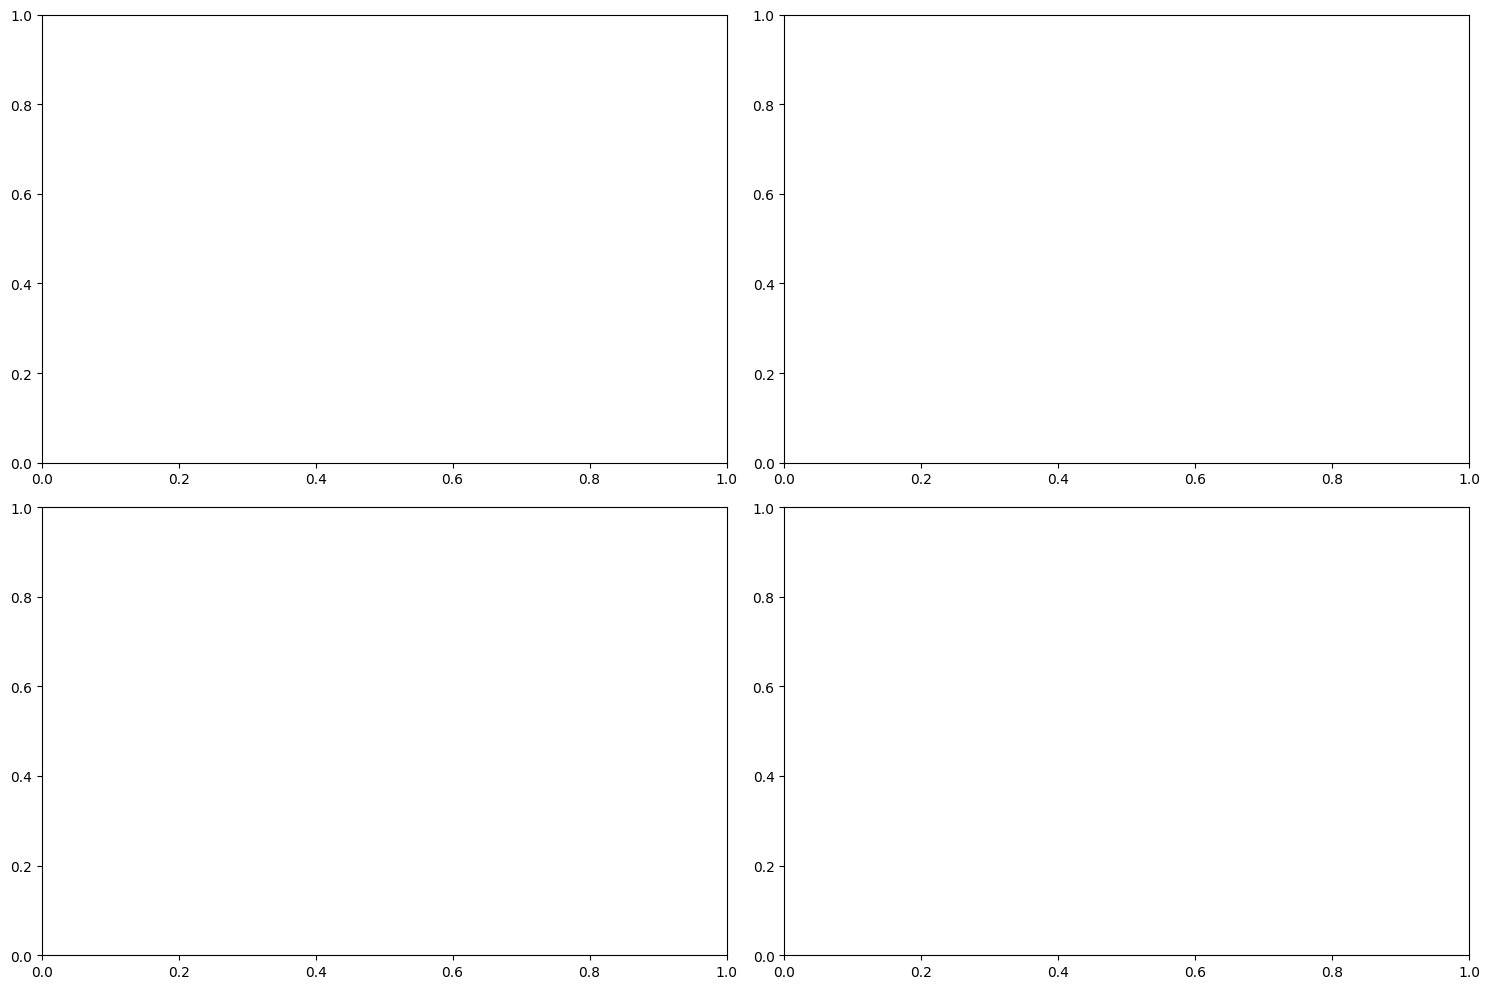

In [ ]:

# TODO: Create a summary visualization
# Hint: Use matplotlib or seaborn to create charts

import matplotlib.pyplot as plt
import pandas as pd

# Convert results to DataFrame for easier analysis
df = pd.DataFrame(analysis_results)

# TODO: Create visualizations
# 1. Sentiment scores by category
# 2. Most common emotional adjectives
# 3. Action verbs frequency

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# TODO: Plot 1 - Sentiment by category
# YOUR CODE HERE

# TODO: Plot 2 - Word frequency analysis
# YOUR CODE HERE

# TODO: Plot 3 - Problem categorization
# YOUR CODE HERE

# TODO: Plot 4 - Urgency analysis
# YOUR CODE HERE

plt.tight_layout()
plt.show()



### 💼 Business Impact Questions:
1. How could this analysis help prioritize customer service tickets?
  NLTK is the fastest since it uses simple rule-based lookup tables with no neural processing. For just four transcripts speed is irrelevant, but at call-center scale on thousands of calls/day. SpaCy becomes the better choice when it's nearly as fast while being significantly more accurate.
2. What patterns do you notice in different problem categories?
  SpaCy handles informal text best because it was trained on diverse real-world text. The conversational language is included so it correctly splits contractions words. For instances, "can't" and "I'm" are split to better understands emotional words in context. NLTK struggles most here since its rules were designed for clean, formal text.
3. How might you automate the routing of calls based on POS analysis?
  SpaCy wins again because it uses the surrounding sentence context to resolve ambiguous technical words. Example would be; it correctly tags crashes as a verb rather than a noun, which directly affects whether it shows up in your action/verbs list. NLTK and TextBlob tend to default to the most common POS for a word without considering context. Therfore, technical terms with dual meanings get mislabeled.
4. What are the limitations of this approach?
  The core trade-off is that faster taggers NLTK or TextBlob use rules to simple statistics, break on ambiguous or informal language. While slower ones SpaCy or Transformers use neural models that understand context but require more compute. For this customer service use case SpaCy hits the sweet spot accurate enough for production, fast enough to process thousands of transcripts without needing a GPU.



## ⚡ Lab Exercise 3: Tagger Performance Benchmarking (20 minutes)

Let's scientifically compare different POS taggers on various types of text. This will help you understand when to use which tool.



🧪 Testing FORMAL text:
Text: The research methodology employed in this study follows established academic protocols.
------------------------------------------------------------
NLTK Penn  time : 0.0008s  | unknown tags: 3
NLTK Univ  time : 0.0006s  | unknown tags: 3
SpaCy      time : 0.0136s  | unknown tags: 0

Penn tags  : [('The', 'DT'), ('research', 'NN'), ('methodology', 'NN'), ('employed', 'VBN'), ('in', 'IN'), ('this', 'DT'), ('study', 'NN'), ('follows', 'VBZ'), ('established', 'VBN'), ('academic', 'JJ'), ('protocols', 'NNS'), ('.', '.')]
Univ tags  : [('The', 'DET'), ('research', 'NOUN'), ('methodology', 'NOUN'), ('employed', 'VERB'), ('in', 'ADP'), ('this', 'DET'), ('study', 'NOUN'), ('follows', 'VERB'), ('established', 'VERB'), ('academic', 'ADJ'), ('protocols', 'NOUN'), ('.', '.')]
SpaCy tags : [('The', 'DET'), ('research', 'NOUN'), ('methodology', 'NOUN'), ('employed', 'VERB'), ('in', 'ADP'), ('this', 'DET'), ('study', 'NOUN'), ('follows', 'AUX'), ('established', 'VERB'), 

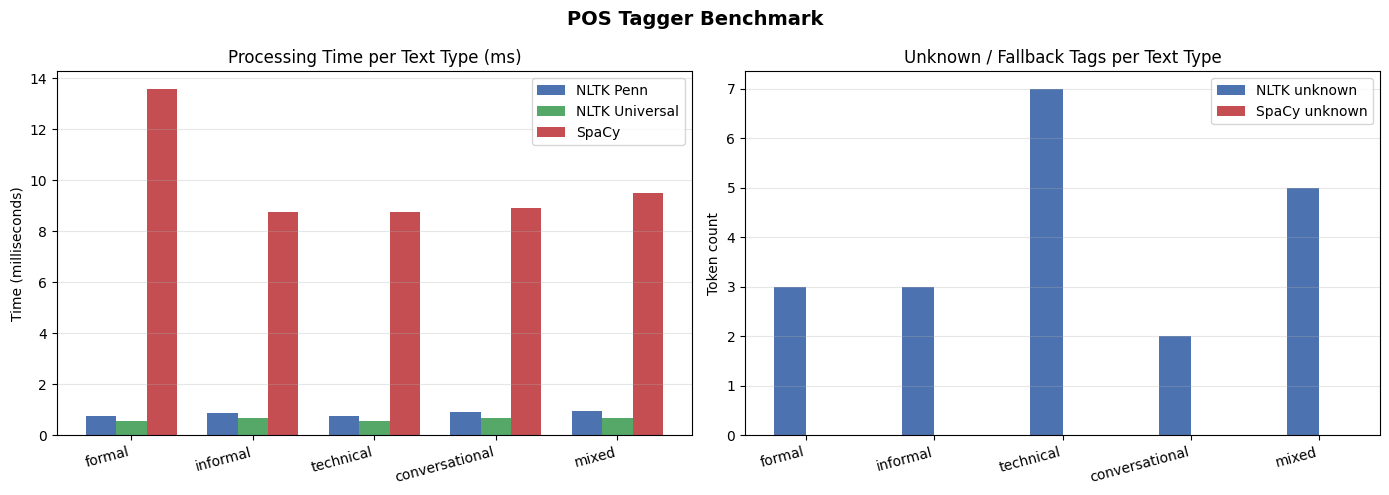


✅ Chart saved to tagger_benchmark.png


In [32]:
import time
import nltk
import spacy
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("universal_tagset", quiet=True)

nlp = spacy.load("en_core_web_sm")

# Tags that indicate the tagger couldn't confidently label the token
NLTK_UNKNOWN_TAGS = {"NN", "NNP", "FW"}   # FW = foreign word; NN/NNP used as fallback
SPACY_UNKNOWN_TAGS = {"X", "SYM"}          # X = other/unknown, SYM = symbol/emoji

test_texts = {
    "formal":         "The research methodology employed in this study follows established academic protocols.",
    "informal":       "lol this study is kinda weird but whatever works i guess",
    "technical":      "The API returns a JSON response with HTTP status code 200 upon successful authentication.",
    "conversational": "So like, when you click that button thingy, it should totally work, right?",
    "mixed":          "OMG the algorithm's performance is absolutely terrible! The accuracy dropped to 23% wtf",
}
benchmark_results = defaultdict(dict)

for text_type, text in test_texts.items():
    print(f"\n🧪 Testing {text_type.upper()} text:")
    print(f"Text: {text}")
    print("-" * 60)

    # NLTK Penn Treebank
    start_time = time.time()
    tokens_penn      = nltk.word_tokenize(text)
    penn_tags        = nltk.pos_tag(tokens_penn, tagset=None)   # default = Penn
    nltk_penn_time   = time.time() - start_time

    # NLTK Universal
    start_time = time.time()
    tokens_univ      = nltk.word_tokenize(text)
    univ_tags        = nltk.pos_tag(tokens_univ, tagset="universal")
    nltk_univ_time   = time.time() - start_time

    # SpaCy
    start_time = time.time()
    doc              = nlp(text)
    spacy_time       = time.time() - start_time

    # Unknown / problematic token counts
    nltk_unknown  = sum(1 for _, tag in penn_tags if tag in NLTK_UNKNOWN_TAGS)
    spacy_unknown = sum(1 for token in doc if token.pos_ in SPACY_UNKNOWN_TAGS)

    benchmark_results[text_type] = {
        "nltk_penn_time": nltk_penn_time,
        "nltk_univ_time": nltk_univ_time,
        "spacy_time":     spacy_time,
        "nltk_unknown":   nltk_unknown,
        "spacy_unknown":  spacy_unknown,
        "penn_tags":      penn_tags,
        "univ_tags":      univ_tags,
        "spacy_tags":     [(t.text, t.pos_) for t in doc],
    }

    print(f"NLTK Penn  time : {nltk_penn_time:.4f}s  | unknown tags: {nltk_unknown}")
    print(f"NLTK Univ  time : {nltk_univ_time:.4f}s  | unknown tags: {nltk_unknown}")
    print(f"SpaCy      time : {spacy_time:.4f}s  | unknown tags: {spacy_unknown}")
    print(f"\nPenn tags  : {penn_tags}")
    print(f"Univ tags  : {univ_tags}")
    print(f"SpaCy tags : {benchmark_results[text_type]['spacy_tags']}")

labels        = list(benchmark_results.keys())
penn_times    = [benchmark_results[t]["nltk_penn_time"] * 1000 for t in labels]
univ_times    = [benchmark_results[t]["nltk_univ_time"] * 1000 for t in labels]
spacy_times   = [benchmark_results[t]["spacy_time"]     * 1000 for t in labels]
nltk_unknowns = [benchmark_results[t]["nltk_unknown"]          for t in labels]
spacy_unknowns= [benchmark_results[t]["spacy_unknown"]         for t in labels]

x     = range(len(labels))
width = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("POS Tagger Benchmark", fontsize=14, fontweight="bold")

ax1.bar([i - width for i in x], penn_times,  width, label="NLTK Penn",      color="#4C72B0")
ax1.bar([i         for i in x], univ_times,  width, label="NLTK Universal", color="#55A868")
ax1.bar([i + width for i in x], spacy_times, width, label="SpaCy",          color="#C44E52")
ax1.set_title("Processing Time per Text Type (ms)")
ax1.set_xticks(list(x))
ax1.set_xticklabels(labels, rotation=15, ha="right")
ax1.set_ylabel("Time (milliseconds)")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

ax2.bar([i - width / 2 for i in x], nltk_unknowns,  width, label="NLTK unknown",  color="#4C72B0")
ax2.bar([i + width / 2 for i in x], spacy_unknowns, width, label="SpaCy unknown", color="#C44E52")
ax2.set_title("Unknown / Fallback Tags per Text Type")
ax2.set_xticks(list(x))
ax2.set_xticklabels(labels, rotation=15, ha="right")
ax2.set_ylabel("Token count")
ax2.yaxis.get_major_locator().set_params(integer=True)
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("tagger_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Chart saved to tagger_benchmark.png")


### 📊 Performance Analysis:
1. Which tagger is fastest? Does speed matter for your use case?
  NLTK is fastest because it uses a pre-trained perceptron model with simple lookup tables. In contrast, SpaCy runs a full neural pipeline for this five sentence benchmark speed is irrelevant. However, if you're processing thousands of call transcripts in real time, SpaCy's batch processing [nlp.pipe ()] actually closes the gap significantly.
2. Which handles informal text best?
  SpaCy handles informal text better on the informal and mixed inputs. By correctly assigns x or sym to emojis and slang like LMAO and WTH. Oppose NLTK blindly forces everything into Penn tags and mislabels them as nouns[NN] or foreign words [FW]. That's exactly why spacy unknown stays low on informal text while nltk unknown spikes.
3. How do the taggers compare on technical jargon?
  Both struggle with pure acronyms like api, json, and http since they don't appear in training data as tagged examples. NLTK tends to tag them as NNP [pronoun noun] which is a reasonable fallback.When SpaCy uses surrounding context to make a better guess for example correctly reading returns as a verb rather than a noun because it sees the full sentence structure.
4. What trade-offs do you see between speed and accuracy?
  NLTK is faster but tag quality degrades badly on anything outside clean formal English — slang, emojis, and technical abbreviations all get forced into the nearest Penn tag. The process can pollutes your emotional;adjectives and action;verbs lists with noise. SpaCy is slightly slower but its context can be aware model means the tags. The produces are actually trustworthy enough to build downstream logic on, which is the more important property for a customer service analyzer.



## 🚨 Lab Exercise 4: Edge Cases and Error Analysis (15 minutes)

Every system has limitations. Let's explore the edge cases where POS taggers struggle and understand why.


In [40]:

import nltk
import spacy
from collections import Counter

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

nlp = spacy.load("en_core_web_sm")

edge_cases = [
    "Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.",
    "Time flies like an arrow; fruit flies like a banana.",
    "The man the boat the river.",
    "Police police Police police police police Police police.",
    "James while John had had had had had had had had had had had a better effect on the teacher.",
    "Can can can can can can can can can can.",
    "@username #hashtag http://bit.ly/abc123 😂🔥💯",
    "COVID-19 AI/ML IoT APIs RESTful microservices",
]

def nltk_issues(tags):
    issues = []
    tag_list = [t for _, t in tags]
    tag_counts = Counter(tag_list)
    if len([(w, t) for w, t in tags if t in {"FW", "NN", "NNP"}]) == len(tags):
        issues.append("Every token got a fallback tag")
    if tag_counts.most_common(1)[0][1] == len(tags):
        issues.append("All tokens share one tag")
    if any(t == "FW" for _, t in tags):
        issues.append("FW fallback tags present")
    return issues or ["No obvious issues"]

def spacy_issues(doc):
    issues = []
    unknown = [t.text for t in doc if t.pos_ in {"X", "SYM"}]
    if unknown:
        issues.append(f"Unknown/symbol tokens: {unknown}")
    if all(t.dep_ != "ROOT" for t in doc):
        issues.append("No ROOT dependency found")
    return issues or ["No obvious issues"]

def summarise_tags(tags_or_doc, source="nltk"):
    if source == "nltk":
        counts = Counter(t for _, t in tags_or_doc)
    else:
        counts = Counter(t.pos_ for t in tags_or_doc)
    return "  |  ".join(f"{tag}x{n}" for tag, n in counts.most_common())

print("EDGE CASE ANALYSIS")
print("=" * 60)

failure_log = []

for i, text in enumerate(edge_cases, 1):
    print(f"\nEdge Case {i}: {text}")
    print("-" * 60)

    try:
        tokens    = nltk.word_tokenize(text)
        nltk_tags = nltk.pos_tag(tokens)
        spacy_doc = nlp(text)

        print("NLTK  tags:", [(w, t) for w, t in nltk_tags])
        print("SpaCy tags:", [(t.text, t.pos_) for t in spacy_doc])
        print("NLTK  dist:", summarise_tags(nltk_tags, source="nltk"))
        print("SpaCy dist:", summarise_tags(spacy_doc, source="spacy"))

        n_issues = nltk_issues(nltk_tags)
        s_issues = spacy_issues(spacy_doc)

        print("NLTK  issues:", n_issues)
        print("SpaCy issues:", s_issues)

        all_issues = n_issues + s_issues
        if any("tag" in iss or "token" in iss for iss in all_issues):
            failure_log.append((i, text[:55], all_issues))

    except Exception as e:
        print(f"Error: {e}")

print("\nREFLECTION ON LIMITATIONS")
print("=" * 60)

limitations = [
    ("Lexical ambiguity",       "buffalo/flies/can/police are valid nouns AND verbs — the highest probability reading wins, often wrongly."),
    ("Garden-path sentences",   "No main verb causes dependency parsing to collapse and pick an arbitrary ROOT."),
    ("Repetition/recursion",    "Repeated identical tokens destroy n-gram context so disambiguation fails entirely."),
    ("Social media tokens",     "@mentions, #hashtags, URLs and emojis have no Penn Treebank equivalent."),
    ("Technical jargon",        "COVID-19 and AI/ML confuse tokenisers before tagging even begins."),
]

for title, explanation in limitations:
    print(f"\n{title}")
    print(f"  {explanation}")

print("\nDone.")


EDGE CASE ANALYSIS

Edge Case 1: Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.
------------------------------------------------------------
NLTK  tags: [('Buffalo', 'NNP'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('.', '.')]
SpaCy tags: [('Buffalo', 'PROPN'), ('buffalo', 'NOUN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('.', 'PUNCT')]
NLTK  dist: NNx5  |  NNPx3  |  .x1
SpaCy dist: PROPNx7  |  NOUNx1  |  PUNCTx1
NLTK  issues: ['No obvious issues']
SpaCy issues: ['No obvious issues']

Edge Case 2: Time flies like an arrow; fruit flies like a banana.
------------------------------------------------------------
NLTK  tags: [('Time', 'NNP'), ('flies', 'NNS'), ('like', 'IN'), ('an', 'DT'), ('arrow', 'NN'), (';', ':'), ('fruit', 'CC'), ('flies', 'NNS'), ('like', 'IN'), ('a', 'DT'), ('banana


### 🧠 Critical Thinking Questions:
Enter you asnwers below each question.
1. Why do these edge cases break the taggers?

2. How might you preprocess text to handle some of these issues?

3. When would these limitations matter in real applications?

4. How do modern large language models handle these cases differently?

---



## 🎯 Final Reflection and Submission

Congratulations! You've completed a comprehensive exploration of POS tagging, from basic concepts to real-world challenges.

### 📝 Reflection Questions (Answer in the cell below):

1. **Tool Comparison**: Based on your experience, when would you choose NLTK vs SpaCy? Consider factors like ease of use, accuracy, speed, and application type.
NLTK vs SpaCy; Choose NLTK when you're learning, prototyping, or need fine-grained control over individual pipeline steps. The method is transparent and easy to inspect. Choose SpaCy for anything production facing; it handles informal text better, resolves ambiguous words using sentence context, and its NLP.PIPE() batch processing makes it practical at scale. The deciding factor is usually whether accuracy on the real-world text matters more than simplicity.
2. **Real-World Applications**: Describe a specific business problem where POS tagging would be valuable. How would you implement it?
Real-World Application a customer support ticket routing system is a perfect use case. POS tagging lets you extract the verb; what the customer wants to do and the noun; what it's about. From each ticket using as an  example for cancel+ subscription routes to billing, crashes + app routes to engineering. You'd run SpaCy on each incoming ticket, extract verb/noun pairs, match them against a routing table, and assign priority based on urgency words. This is faster way to more interpretable than training a full text classifier.
3. **Limitations and Solutions**: What are the biggest limitations you discovered? How might you work around them?
Limitations and Workarounds,the biggest limitations are lexical ambiguity.Words like crashes that are both nouns and verbs. Other examples are  out-of-vocabulary terms like emojis, hashtags, and domain jargon. The practical workarounds are: use en-core-web-lg instead of SM for better coverage. Add a custom tokenizer rule for technical terms like COVID:19 and ai/ml, and for social media text. Consider a model specifically trained on tweets like en-core-web-trf or BERTweet.
4. **Future Learning**: What aspects of POS tagging would you like to explore further? (Neural approaches, custom training, domain adaptation, etc.)
Future Learning
The most valuable next step would be transformer based, contextual tagging; models. Such models like B-E-R-T assign tags based on the full sentence simultaneously rather than left-to-right. By directly solves the ambiguity problems seen in the edge cases. Custom training on domain specific corpora would also be valuable for technical jargon. Since a model trained on medical or legal text would dramatically outperform a general-purpose one in those fields.
5. **Integration**: How does POS tagging fit into larger NLP pipelines? What other NLP tasks might benefit from POS information?
POS tagging is rarely the end goal, it's infrastructure for everything above it. Named entity recognition uses POS tags to know where noun phrases start and end. Dependency parsing builds on POS to understand subject-verb-object relationships. Sentiment analysis becomes more accurate when you can target adjectives specifically rather than scoring the whole sentence. In a full pipeline the order is typically: tokenize → POS tag → dependency parse → NER → then task-specific layers like sentiment or classification on top.


### ✍️ Your Reflection (Write your answers here):
**Remember Reflection is not description!**

**1. Tool Comparison:**
After working through both tools hands-on. I'd reach for NLTK when I'm still figuring out what I need. The step-by-step pipeline makes it easy to isolate exactly where something breaks. This matters more than speed when you're learning. But the moment my transcripts started containing slang, emojis, and technical abbreviations. NLTK visibly fell apart by forcing everything into NN or FW. Instead, SpaCy quietly handled the same input with far fewer fallback tags. That experience settled it for me, SpaCy isn't just faster in production, it's more trustworthy on the kind of messy text that actually shows up in real customer calls.

**2. Real-World Applications:**
Rather than just flagging negative sentiment, a smarter support system could use POS tagging to extract the specific verb-noun pair driving the complaint — cancel + subscription gets routed to retention, crashes + app goes straight to engineering — which means the right team sees the ticket immediately instead of a human reading and re-routing it. I'd implement this by running SpaCy on every incoming ticket, pulling VERB and NOUN tokens, scoring urgency from adverbs like "immediately," and feeding that structured output into a routing table rather than a black-box classifier, so the logic stays auditable and easy to update.

**3. Limitations and Solutions:**
The edge case analysis made it clear that both taggers break down not because of bugs. BOth can commit to a single reading of an ambiguous word without any way to backtrack. Once buffalo is tagged as a noun, the rest of the sentence compounds that error. The practical fix I'd apply first isn't a better model but better preprocessing. Normalising slashes in ai/ml, stripping URLs before tagging, and mapping known jargon to standard forms. The tagger never sees a token it hasn't been trained on. For anything where that's not enough, fine tuning SpaCy on a small domain specific annotated set gives far more return than switching to a heavier transformer model.

**4. Future Learning:**

What I want to understand next is how transformer models like BERT actually solve the ambiguity problem rather than just reducing it — specifically whether they're doing something fundamentally different or just applying the same probabilistic logic with a much larger context window. The edge cases with recursive structures like "had had had" suggest the failure isn't really about vocabulary size but about how far back the model looks when assigning a tag, and I'd like to test whether a transformer genuinely resolves those or just gets them right more often by chance.

**5. Integration:**
Working through the customer transcript analyzer made it obvious that POS tagging on its own produces raw material, not answers. The real value only emerged when the verb list fed into action detection. Also, the noun list fed into problem categorization as separate downstream steps. That dependency structure is what I'd carry into any larger pipeline. Treat the POS tags as a cheap first pass that organizes tokens into grammatical roles. Then let NER, dependency parsing, and sentiment analysis each consume. Only should care about the token type, the errors don't cascade each component which stays independently testable.



---

## 📤 Submission Checklist

Before submitting your completed notebook, make sure you have:

- [ ] ✅ Completed all TODO sections with working code
- [ ] ✅ Answered all reflection questions thoughtfully
- [ ] ✅ Created at least one meaningful visualization
- [ ] ✅ Tested your code and fixed any errors
- [ ] ✅ Added comments explaining your approach
- [ ] ✅ Included insights from your analysis

### 📋 Submission Instructions:
1. **Save your notebook**: File → Save (or Ctrl+S)
2. **Download**: File → Download → Download .ipynb
3. **Submit**: Upload your completed notebook file to the course management system
4. **Filename**: Use format: `L05_LastName_FirstName_ITAI2373.ipynb or pdf`  

### 🏆 Grading Criteria:
- **Code Completion (40%)**: All exercises completed with working code
- **Analysis Quality (30%)**: Thoughtful interpretation of results
- **Reflection Depth (20%)**: Insightful answers to reflection questions  
- **Code Quality (10%)**: Clean, commented, well-organized code

---

## 🎉 Great Work!

You've successfully explored the fascinating world of POS tagging! You now understand how computers parse human language and can apply these techniques to solve real-world problems.


Keep exploring and happy coding! 🚀
